In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import time
import os
from tqdm import tqdm
from transformers import AutoModel

print("Setting up Data Loaders for Phase 2 (Phikon)...")

# 1. Hardware Setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device locked to: {device}")

# 2. Vision Transformer Transforms
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Load the Main Folder
full_dataset = datasets.ImageFolder(root='Augmented_LC25000_train', transform=data_transforms)
class_names = full_dataset.classes

# 4. Calculate the 80/10/10 split
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# 5. THE SCIENTIFIC LOCK: Use the exact same random seed as Phase 1!
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=generator
)

# 6. Create the Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Data perfectly split! Train: {train_size}, Val: {val_size}, Test: {test_size}")
print(f"Targeting 5 Classes: {class_names}")

Setting up Data Loaders for Phase 2 (Phikon)...
Device locked to: mps
Data perfectly split! Train: 144000, Val: 18000, Test: 18000
Targeting 5 Classes: ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


In [23]:
# ==========================================
# DEFINE THE PHIKON (ViT) ARCHITECTURE
# ==========================================
class StreamB_Phikon(nn.Module):
    def __init__(self, num_classes=5):
        super(StreamB_Phikon, self).__init__()
        # Download the Medical Expert (This may take a minute the first time!)
        self.base = AutoModel.from_pretrained("owkin/phikon")
        
        # Freeze the pre-trained medical brain
        for param in self.base.parameters():
            param.requires_grad = False
            
        # Phikon outputs a 768-dimensional vector
        self.head = nn.Sequential(
            nn.Linear(768, 256),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        outputs = self.base(x)
        # VISION TRANSFORMER MAGIC: Extract the [CLS] token (the 0th sequence item)
        features = outputs.last_hidden_state[:, 0, :] 
        logits = self.head(features)
        return logits

# Initialize Model
model = StreamB_Phikon(num_classes=5).to(device)

# The "Humility Tax" (Label Smoothing)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Weight Decay to keep weights small
optimizer = optim.Adam(model.head.parameters(), lr=0.001, weight_decay=1e-4)

# The Plateau Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Setup the permanent Log File
log_filename = "phikon_training_log.txt"
with open(log_filename, "w") as f:
    f.write("Epoch,Train_Acc,Train_Loss,Val_Acc,Val_Loss,Time_Seconds\n")

print("\nPhikon ViT Architecture loaded!")
print(f"Permanent log file '{log_filename}' created.")


Phikon ViT Architecture loaded!
Permanent log file 'phikon_training_log.txt' created.


In [ ]:
num_epochs = 30
best_val_loss = float('inf')

print("Starting 30-Epoch Phase 2 Training (Stream B: Phikon)...")

for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train() 
    running_loss, correct, total = 0.0, 0, 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Train]", leave=True)
    
    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad() 
        outputs = model(inputs) 
        loss = criterion(outputs, labels) 
        loss.backward() 
        optimizer.step() 
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        live_acc = correct / total
        live_loss = running_loss / total
        train_bar.set_postfix(loss=f"{live_loss:.4f}", acc=f"{live_acc*100:.2f}%")
        
    train_acc = correct / total
    train_loss = running_loss / total
    
    # --- VALIDATION PHASE ---
    model.eval() 
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Val]", leave=False)
    
    with torch.no_grad():
        for inputs, labels in val_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            live_val_acc = val_correct / val_total
            live_val_loss = val_loss / val_total
            val_bar.set_postfix(loss=f"{live_val_loss:.4f}", acc=f"{live_val_acc*100:.2f}%")
            
    val_acc = val_correct / val_total
    val_loss = val_loss / val_total
    
    # Trigger the learning rate scheduler
    scheduler.step(val_loss)
    
    # --- END OF EPOCH SUMMARY & LOGGING ---
    epoch_time = time.time() - start_time
    print(f"\nEpoch {epoch+1:02d}/{num_epochs} Complete | Time: {epoch_time:.0f}s")
    print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% | Val Loss: {val_loss:.4f}")
    
    # PERMANENT LOGGING
    with open(log_filename, "a") as f:
        f.write(f"{epoch+1},{train_acc:.4f},{train_loss:.4f},{val_acc:.4f},{val_loss:.4f},{epoch_time:.0f}\n")
    
    # SAVING CHECKPOINTS
    epoch_filename = f'phikon_epoch_{epoch+1:02d}.pth'
    torch.save(model.state_dict(), epoch_filename)
    print(f"--> Saved checkpoint: {epoch_filename}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print("    (★ New best validation score! Updating 'phikon_best_overall.pth')")
        torch.save(model.state_dict(), 'phikon_best_overall.pth')
        
    print("-" * 50) 

print("Phase 2 (Stream B) 30-Epoch Run Complete!")

Starting 30-Epoch Phase 2 Training (Stream B: Phikon)...


Epoch 01/30 [Train]: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4500/4500 [1:08:54<00:00,  1.09it/s, acc=95.46%, loss=0.5168]
                                                                                                                                                                                                                     


Epoch 01/30 Complete | Time: 4654s
Train Acc: 95.46% | Val Acc: 97.04% | Val Loss: 0.4654
--> Saved checkpoint: phikon_epoch_01.pth
    (★ New best validation score! Updating 'phikon_best_overall.pth')
--------------------------------------------------


Epoch 02/30 [Train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4500/4500 [53:51<00:00,  1.39it/s, acc=96.44%, loss=0.4999]
                                                                                                                                                                                                                     


Epoch 02/30 Complete | Time: 3625s
Train Acc: 96.44% | Val Acc: 97.43% | Val Loss: 0.4592
--> Saved checkpoint: phikon_epoch_02.pth
    (★ New best validation score! Updating 'phikon_best_overall.pth')
--------------------------------------------------


Epoch 03/30 [Train]:   1%|█▌                                                                                                                              | 56/4500 [00:40<48:50,  1.52it/s, acc=96.04%, loss=0.5027]

In [39]:
class StreamB_Phikon(nn.Module):
    def __init__(self, num_classes=5):
        super(StreamB_Phikon, self).__init__()
        # Load the original Phikon base (matches your 98.8% weights)
        self.base = AutoModel.from_pretrained("owkin/phikon")
        
        # Freeze the base for evaluation (saves memory)
        for param in self.base.parameters():
            param.requires_grad = False
            
        # The 768-dimensional classification head
        self.head = nn.Sequential(
            nn.Linear(768, 256), 
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        outputs = self.base(x)
        # Extract [CLS] token
        features = outputs.last_hidden_state[:, 0, :] 
        logits = self.head(features)
        return logits

Building the empty model shell...
Loading the champion weights...

Running Final Deep Evaluation on Unseen Test Set...


Calculating Metrics: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 563/563 [06:17<00:00,  1.49it/s]


FINAL TEST LOSS:     0.4276
FINAL TEST ACCURACY: 98.67%

FINAL CLASSIFICATION REPORT: STREAM B (PHIKON-V2)
              precision    recall  f1-score   support

   colon_aca     0.9983    0.9980    0.9982      3554
     colon_n     0.9989    0.9983    0.9986      3575
    lung_aca     0.9625    0.9750    0.9687      3607
      lung_n     0.9980    0.9961    0.9970      3547
    lung_scc     0.9766    0.9669    0.9717      3717

    accuracy                         0.9867     18000
   macro avg     0.9869    0.9869    0.9869     18000
weighted avg     0.9867    0.9867    0.9867     18000



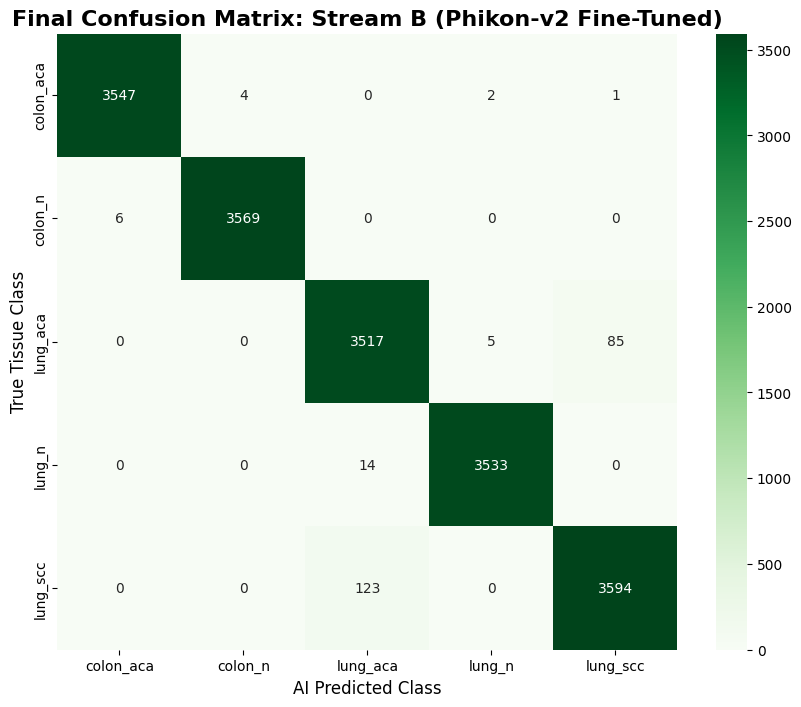

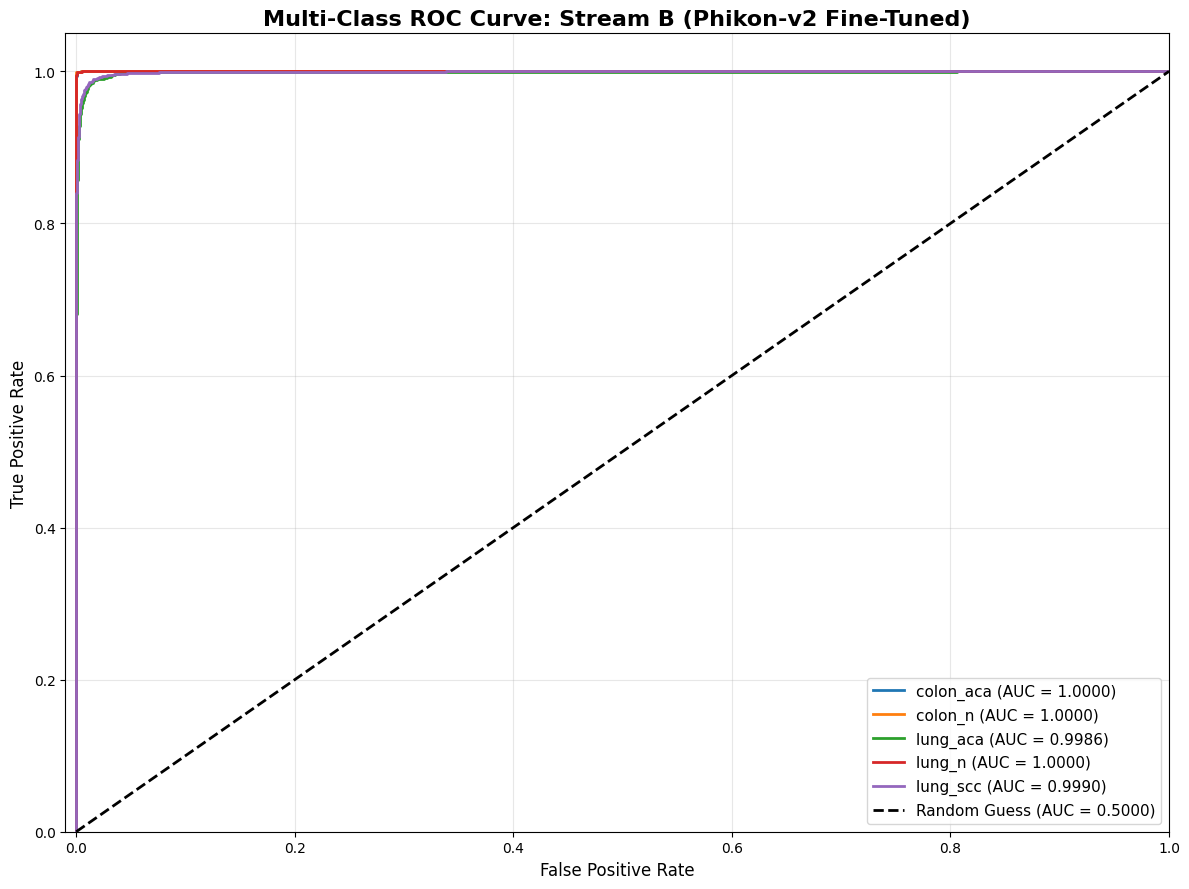

In [40]:
import torch
import torch.nn as nn
from transformers import AutoModel
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================
# 2. INITIALIZE AND LOAD THE CHAMPION MODEL
# ==========================================
print("Building the empty model shell...")
best_model = StreamB_Phikon(num_classes=5).to(device)

print("Loading the champion weights...")
best_model_path = 'phikon_best_overall.pth' 

# THE FIX IS HERE: strict=False tells PyTorch not to panic about the missing Hugging Face keys!
best_model.load_state_dict(torch.load(best_model_path, map_location=device), strict=False)
best_model.eval() # Pencils down! No dropout during the final test.

# ==========================================
# 3. COLLECT PROBABILITIES & PREDICTIONS
# ==========================================
all_probs = []
all_preds = []
all_labels = []

print("\nRunning Final Deep Evaluation on Unseen Test Set...")
test_bar = tqdm(test_loader, desc="Calculating Metrics", leave=True)
running_test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        logits = best_model(inputs)

        loss = criterion(logits, labels)
        running_test_loss += loss.item() * inputs.size(0)
        
        probs = torch.nn.functional.softmax(logits, dim=1) 
        _, predicted = torch.max(logits, 1) 
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

test_loss = running_test_loss / len(test_loader.dataset)
test_accuracy = (all_preds == all_labels).mean()

print("\n" + "="*50)
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print(f"FINAL TEST ACCURACY: {test_accuracy*100:.2f}%")
print("="*50)

# ==========================================
# 4. TEXT REPORT: CLASSIFICATION REPORT
# ==========================================
print("\n" + "="*50)
print("FINAL CLASSIFICATION REPORT: STREAM B (PHIKON-V2)")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# ==========================================
# 5. VISUAL 1: THE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Final Confusion Matrix: Stream B (Phikon-v2 Fine-Tuned)', fontsize=16, fontweight='bold')
plt.ylabel('True Tissue Class', fontsize=12)
plt.xlabel('AI Predicted Class', fontsize=12)
plt.show()

# ==========================================
# 6. VISUAL 2: MULTI-CLASS ROC-AUC CURVE
# ==========================================
num_classes = len(class_names)
binarized_labels = label_binarize(all_labels, classes=range(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(binarized_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(12, 9))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] 

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess (AUC = 0.5000)')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-Class ROC Curve: Stream B (Phikon-v2 Fine-Tuned)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()